In [3]:
import numpy as np                 #numpy is a library for array operations akin to MATLAB
from matplotlib import pyplot as plt    #matplotlib is 2D plotting library
%matplotlib inline

def linearconv(nx):
    #The input to the function is the number of grid cells in the x-range [0,2]
    dx = 2 / (nx - 1) # The size of the grid cell in the x dimension
    nt = 20    #nt is the number of timesteps we want to calculate
    dt = .025  #dt is the amount of time each timestep covers (delta t)
    a = 1

    u = np.ones(nx)      #defining a numpy array which is nx elements long with every value equal to 1.
    u[int(.5/dx):int(1 / dx + 1)] = 2  #setting u = 2 between 0.5 and 1 --> initial condition
    plt.plot(np.linspace(0, 2, nx), u,label='initial signal');

    un = np.ones(nx) #initializing our placeholder array, un, to hold the values we calculate for the n+1 timestep

    for n in range(nt):  #iterate through time
        un = u.copy() ##copy the existing values of u into un
        for i in range(1, nx):
            u[i] = un[i] - a * dt / dx * (un[i] - un[i-1]) #Can you recognize what scheme this is???
        
    plt.plot(np.linspace(0, 2, nx), u,label='model nx={}'.format(nx));
    plt.legend(fontsize=14)
    plt.ylabel('T(x, N=20)',fontsize=14)
    plt.xlabel('spatial dimension x',fontsize=14)

    plt.yticks(fontsize=12)
    plt.xticks(fontsize=12)
    plt.show()

    #plt.savefig(('LinearConv_nx'+np.str(nx)),dpi=300, facecolor='w', edgecolor='w',
    #      orientation='landscape', format=None,
    #      transparent=False, bbox_inches=None,pad_inches=0.25)
    

ModuleNotFoundError: No module named 'numpy'

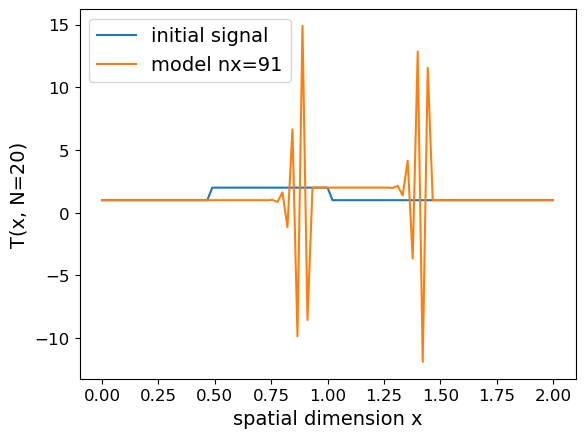

In [5]:
linearconv(91) #convection using xx grid points

In [2]:
print(1*0.025/(2/31))

0.3875


In [10]:
def linearconv_CFL095(nx):
    #The input to the function is the number of grid cells in the x-range [0,2]
    dx = 2 / (nx - 1) # The size of the grid cell in the x dimension
    nt = 20    #nt is the number of timesteps we want to calculate
    a = 1
    sigma=0.95
    dt = sigma*dx/a  #dt is the amount of time each timestep covers (delta t)
    

    u = np.ones(nx)      #defining a numpy array which is nx elements long with every value equal to 1.
    u[int(.5/dx):int(1 / dx + 1)] = 2  #setting u = 2 between 0.5 and 1 --> initial condition
    plt.plot(np.linspace(0, 2, nx), u,label='initial signal');

    un = np.ones(nx) #initializing our placeholder array, un, to hold the values we calculate for the n+1 timestep

    for n in range(nt):  #iterate through time
        un = u.copy() ##copy the existing values of u into un
        for i in range(1, nx):
            u[i] = un[i] - a * dt / dx * (un[i] - un[i-1]) #Can you recognize what scheme this is???
        
    plt.plot(np.linspace(0, 2, nx), u,label='model nx={}'.format(nx));
    plt.legend(fontsize=14)
    plt.ylabel('T(x, N=20)',fontsize=14)
    plt.xlabel('spatial dimension x',fontsize=14)

    plt.yticks(fontsize=12)
    plt.xticks(fontsize=12)
    plt.show()

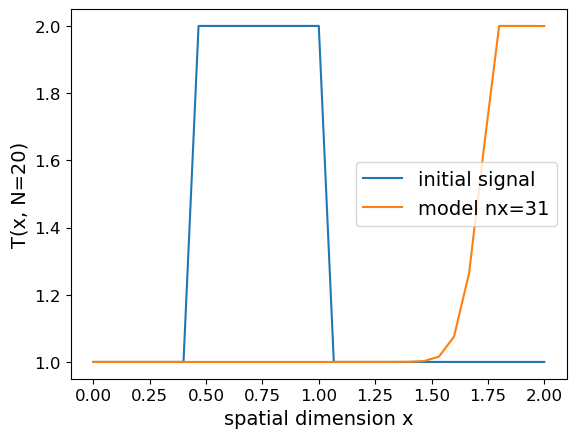

In [12]:
linearconv_CFL095(31)

In [13]:
def linearconv_CFL095_05sec(nx):
    #The input to the function is the number of grid cells in the x-range [0,2]
    dx = 2 / (nx - 1) # The size of the grid cell in the x dimension
    a = 1
    sigma=0.95
    dt = sigma*dx/a  #dt is the amount of time each timestep covers (delta t)
    nt = int(0.5/dt)    #run for 0.5 seconds
    

    u = np.ones(nx)      #defining a numpy array which is nx elements long with every value equal to 1.
    u[int(.5/dx):int(1 / dx + 1)] = 2  #setting u = 2 between 0.5 and 1 --> initial condition
    plt.plot(np.linspace(0, 2, nx), u,label='initial signal');

    un = np.ones(nx) #initializing our placeholder array, un, to hold the values we calculate for the n+1 timestep

    for n in range(nt):  #iterate through time
        un = u.copy() ##copy the existing values of u into un
        for i in range(1, nx):
            u[i] = un[i] - a * dt / dx * (un[i] - un[i-1]) #Can you recognize what scheme this is???
        
    plt.plot(np.linspace(0, 2, nx), u,label='model nx={}'.format(nx));
    plt.legend(fontsize=14)
    plt.ylabel('T(x, N=20)',fontsize=14)
    plt.xlabel('spatial dimension x',fontsize=14)

    plt.yticks(fontsize=12)
    plt.xticks(fontsize=12)
    plt.show()
    print(dt)
    print(nt)

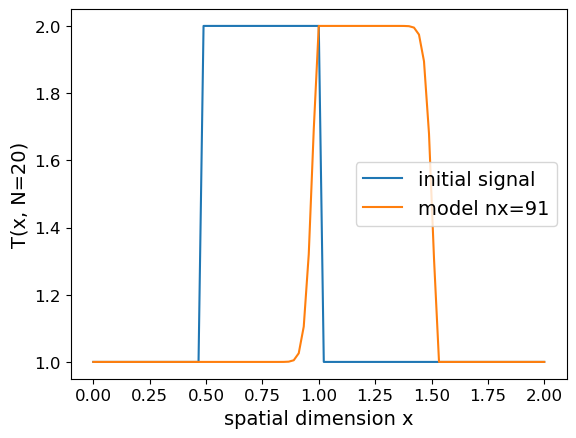

0.021111111111111112
23


In [14]:
linearconv_CFL095_05sec(91)

$\bar{u}_t + c \bar{u}_x = -{{\Delta t} \over 2} c^2 \bar{u}_{xx} + O({\Delta t^2}, \Delta x^2)$
Negative diffusion coefficient represents an explosion (unstable)

In contrast, 1st order upwind for 1D convection:
$\bar{u}_t + c \bar{u}_x = {{c \Delta x} \over 2} (1+{{c \Delta t} \over {\Delta x}}) \bar{u}_{xx}$
Contained numerical diffusion proportional to \(\Delta x\) (first order) which is why the diffusion is excessive

Stability condition \(c \gt 0\) and \(\sigma = {{c \Delta t} \over \Delta x}\) (CFL Condition)